# 04 · The descriptive inflation story  (Part 1)

Question of the project: **when should a Buenos Aires hotel category change its
price?** This notebook sets up the problem — inflation erodes the *real* value
of a fixed nominal rate, so the hotel must reprice; but each repricing has
operational / customer friction, so it should not reprice mechanically every
month.

* **Long-run context** 2008–2026: nominal rate vs CPI vs real rate (Chart 1, 2).
* **Main analysis sample**: `2018-01…2019-12 + 2022-01…2026-05`.
  **COVID 2020–2021 is held out** (tourism collapse + missing category detail).
* How fast does inaction erode the real price? (mechanical illustration)
* Table 1 — descriptive statistics by category, main sample.

**Input** `03_analysis_panel.parquet` → **Output** `outputs/figures/04_*.png`,
`chart1_*`, `chart2_*`, `outputs/tables/table1_descriptives.csv`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

SRC = Path.cwd().parent / "src"
sys.path.insert(0, str(SRC))
import config as C
from common import AuditLog

LOG = AuditLog("04_descriptive")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": C.PLOT_DPI, "font.size": 9,
                     "axes.grid": True, "grid.alpha": .3, "axes.axisbelow": True})

df = pd.read_parquet(C.P_ANALYSIS)
LAB = C.CATEGORY_LABELS
COV = (pd.Timestamp(C.COVID_START), pd.Timestamp(C.COVID_END))
CATS = C.CORE_CATEGORIES + [C.COMPOSITE_TOTAL]


def covid_band(ax):
    ax.axvspan(*COV, color="0.6", alpha=.28, lw=0, zorder=0)


def sample_bands(ax):
    """Light shading of the two analysis segments."""
    for a, b in C.ANALYSIS_SEGMENTS:
        ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color="tab:blue", alpha=.05, lw=0)


def save(fig, name):
    fig.tight_layout(); fig.savefig(C.OUT_FIG / name); LOG.log("figure", name); plt.show()

## Chart 1 — "Inflation turned hotel pricing into a moving target"

2008–2026, indexed to 100 at 2018-01 (log scale). Nominal hotel rate and CPI
both rise ~1000×; the question is whether the nominal rate kept up in *real*
terms.

  [04_descriptive] figure                 04_chart1_moving_target.png                


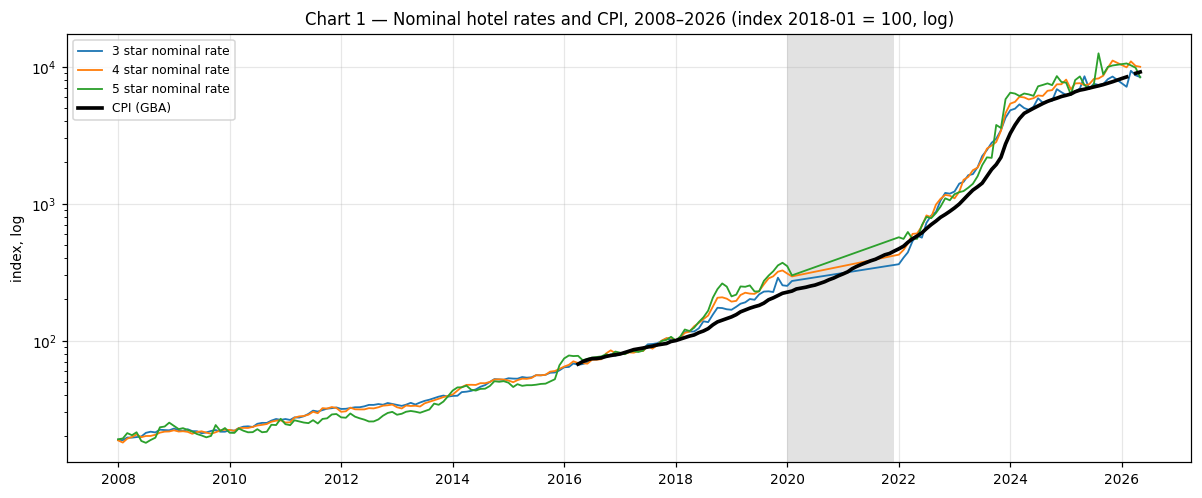

In [2]:
b0 = pd.Timestamp("2018-01-01")
fig, ax = plt.subplots(figsize=(11, 4.6))
piv = df.pivot_table(index="date", columns="hotel_category", values="average_rate")
cpi = df.groupby("date")["cpi_gba"].first()
for cat in ["stars_3", "stars_4", "stars_5"]:
    s = piv[cat].dropna()
    ax.plot(s.index, s / s.loc[b0] * 100, lw=1.2, label=f"{LAB[cat]} nominal rate")
ax.plot(cpi.index, cpi / cpi.loc[b0] * 100, lw=2.4, color="k", label="CPI (GBA)")
covid_band(ax)
ax.set_yscale("log")
ax.set_title("Chart 1 — Nominal hotel rates and CPI, 2008–2026 (index 2018-01 = 100, log)")
ax.set_ylabel("index, log")
ax.legend(fontsize=8)
save(fig, "04_chart1_moving_target.png")

## Chart 2 — "Nominal prices rose — but did real prices?"

Real rate = nominal ÷ CPI × 100 (constant dic-2016 pesos). A flat line = the
rate exactly kept pace with inflation. Deviations show real over- and
under-shooting. Only shown where the deflator exists (GBA CPI from 2016-04).

  [04_descriptive] figure                 04_chart2_nominal_vs_real.png              


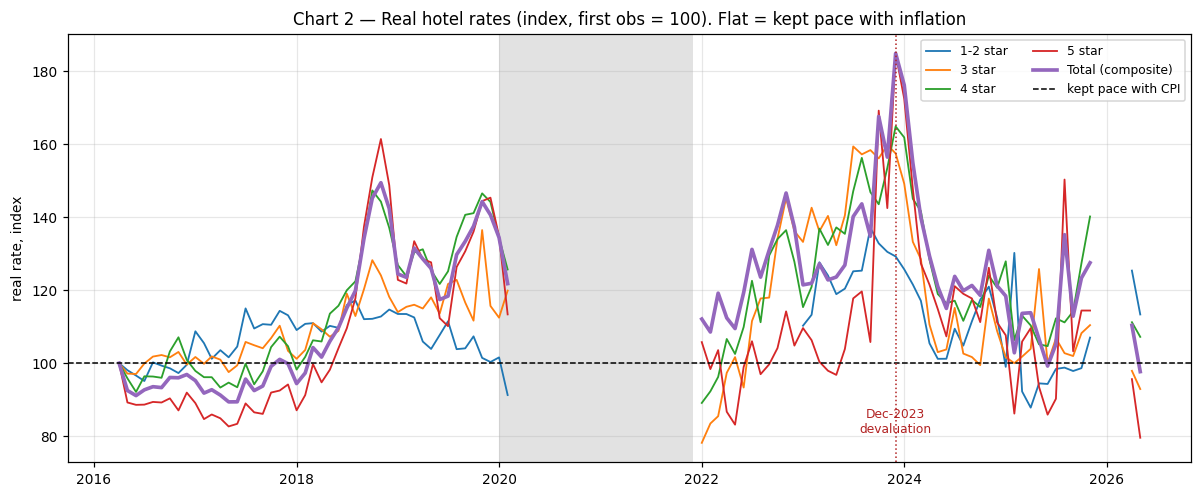

In [3]:
full = pd.date_range("2016-04-01", C.DATA_END, freq="MS")
fig, ax = plt.subplots(figsize=(11, 4.6))
for cat in CATS:
    s = (df[df.hotel_category == cat].set_index("date")["real_rate_gba"].reindex(full))
    base = s.dropna()
    if base.empty:
        continue
    lw = 2.4 if cat == C.COMPOSITE_TOTAL else 1.2
    ax.plot(full, s / base.iloc[0] * 100, lw=lw, label=LAB[cat])
ax.axhline(100, color="k", ls="--", lw=1, label="kept pace with CPI")
covid_band(ax)
ax.axvline(pd.Timestamp("2023-12-01"), color="firebrick", ls=":", lw=1)
ax.annotate("Dec-2023\ndevaluation", (pd.Timestamp("2023-12-01"), ax.get_ylim()[0] + 8),
            color="firebrick", fontsize=8, ha="center")
ax.set_title("Chart 2 — Real hotel rates (index, first obs = 100). Flat = kept pace with inflation")
ax.set_ylabel("real rate, index")
ax.legend(fontsize=8, ncol=2)
save(fig, "04_chart2_nominal_vs_real.png")

## How fast does inaction erode the real price?

Mechanical: if a hotel froze its nominal rate at month 0, the real value after
k months is `1 / Π(1+π)`. Shown at the mean monthly inflation of each regime
and of the whole main sample.

  [04_descriptive] figure                 04_erosion_clock.png                       


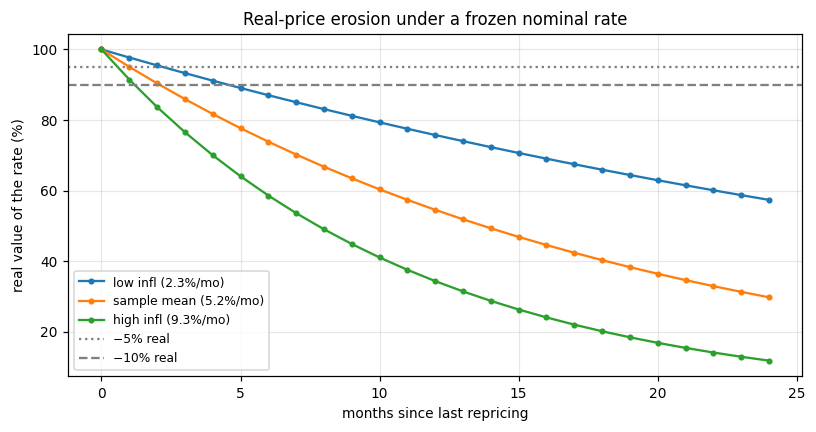

  [04_descriptive] erosion_clock          months to -5% / -10% real                  low: 3 / 5 mo; high: 1 / 2 mo


In [4]:
insamp = df[(df.in_sample == 1) & (df.hotel_category == "stars_4")]
pi_mean = insamp["infl_mom_gba_frac"].mean()
pi_hi = insamp.loc[insamp["infl_mom_gba"] >
                   insamp["infl_mom_gba"].quantile(2 / 3), "infl_mom_gba_frac"].mean()
pi_lo = insamp.loc[insamp["infl_mom_gba"] <
                   insamp["infl_mom_gba"].quantile(1 / 3), "infl_mom_gba_frac"].mean()
k = np.arange(0, 25)
fig, ax = plt.subplots(figsize=(7.5, 4))
for pi, lab in [(pi_lo, f"low infl ({pi_lo:.1%}/mo)"),
                (pi_mean, f"sample mean ({pi_mean:.1%}/mo)"),
                (pi_hi, f"high infl ({pi_hi:.1%}/mo)")]:
    ax.plot(k, 100 / (1 + pi) ** k, marker="o", ms=3, label=lab)
ax.axhline(95, color="0.5", ls=":", label="−5% real")
ax.axhline(90, color="0.5", ls="--", label="−10% real")
ax.set_xlabel("months since last repricing"); ax.set_ylabel("real value of the rate (%)")
ax.set_title("Real-price erosion under a frozen nominal rate")
ax.legend(fontsize=8)
save(fig, "04_erosion_clock.png")
LOG.log("erosion_clock", "months to -5% / -10% real",
        detail=f"low: {np.argmax(100/(1+pi_lo)**k < 95)} / {np.argmax(100/(1+pi_lo)**k < 90)} mo; "
               f"high: {np.argmax(100/(1+pi_hi)**k < 95)} / {np.argmax(100/(1+pi_hi)**k < 90)} mo")

## Table 1 — descriptive statistics by category (main sample, COVID held out)

In [5]:
S = df[(df.in_sample == 1) & df.hotel_category.isin(C.MODEL_CATEGORIES + [C.COMPOSITE_TOTAL])]
rows = []
for cat, s in S.groupby("hotel_category"):
    s = s.sort_values("date")
    rate_mom = np.exp(s["dln_average_rate"]) - 1
    real = s["real_rate_gba"].dropna()
    rows.append(dict(
        hotel_category=cat, label=LAB[cat], n_months=len(s),
        nominal_rate_mean=s["average_rate"].mean(),
        real_rate_mean=real.mean(), real_rate_cv_pct=real.std() / real.mean() * 100,
        real_rate_min_pct_of_mean=real.min() / real.mean() * 100,
        room_occ_mean=s["room_occupancy"].mean(), room_occ_sd=s["room_occupancy"].std(),
        rate_mom_mean_pct=rate_mom.mean() * 100, rate_mom_sd_pct=rate_mom.std() * 100,
        cpi_mom_mean_pct=s["infl_mom_gba"].mean(),
        share_months_rate_up=(s["dln_average_rate"] > 0).mean(),
        share_months_rate_gt_cpi=(s["dln_average_rate"] >
                                  np.log1p(s["infl_mom_gba"] / 100)).mean(),
    ))
tab1 = pd.DataFrame(rows).set_index("hotel_category").round(3)
tab1.to_csv(C.OUT_TAB / "table1_descriptives.csv")
LOG.log("write", "table1_descriptives.csv", len(tab1))
tab1

  [04_descriptive] write                  table1_descriptives.csv                 7  


,label,n_months,nominal_rate_mean,real_rate_mean,real_rate_cv_pct,real_rate_min_pct_of_mean,room_occ_mean,room_occ_sd,rate_mom_mean_pct,rate_mom_sd_pct,cpi_mom_mean_pct,share_months_rate_up,share_months_rate_gt_cpi
hotel_category,,,,,,,,,,,,,
apart,Apart-hotel,77,39631.657,1160.897,15.826,67.715,59.868,7.311,6.071,12.423,5.183,0.779,0.468
boutique,Boutique,77,65941.297,2010.345,13.363,75.289,66.254,7.286,6.014,9.093,5.183,0.727,0.558
stars_1_2,1-2 star,77,21676.175,563.977,9.763,78.434,48.787,7.746,4.915,8.453,5.183,0.636,0.377
stars_3,3 star,77,25167.866,783.930,16.416,66.696,62.081,7.393,6.393,9.475,5.183,0.701,0.468
stars_4,4 star,77,40677.045,1230.960,13.355,71.559,64.285,8.050,6.520,8.181,5.183,0.753,0.506
stars_5,5 star,77,104707.807,3191.117,18.962,68.915,62.862,9.955,6.609,16.660,5.183,0.610,0.442
total_composite,Total (composite),75,51589.878,1568.640,13.888,75.191,61.665,7.098,7.061,13.678,5.248,0.760,0.520


## Sample map — what is in / out

  [04_descriptive] figure                 04_sample_map.png                          


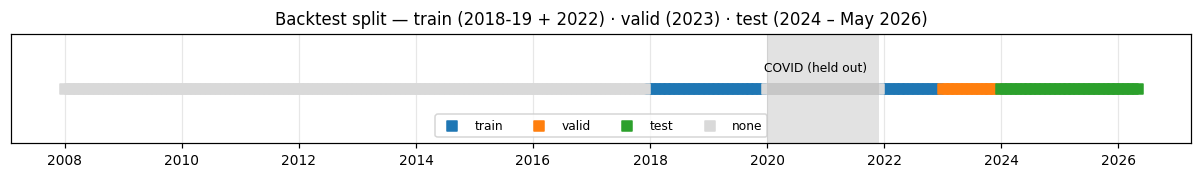

In [6]:
fig, ax = plt.subplots(figsize=(11, 1.7))
s4 = df[df.hotel_category == "stars_4"].sort_values("date")
colors = {"train": "tab:blue", "valid": "tab:orange", "test": "tab:green", "none": "0.85"}
for sp, c in colors.items():
    m = s4["split"] == sp
    ax.scatter(s4.loc[m, "date"], np.zeros(m.sum()), c=c, s=40, marker="s", label=sp)
ax.axvspan(*COV, color="0.6", alpha=.28, lw=0)
ax.annotate("COVID (held out)", (pd.Timestamp("2020-11-01"), .015), ha="center", fontsize=8)
ax.set_yticks([]); ax.set_ylim(-.05, .05)
ax.set_title("Backtest split — train (2018-19 + 2022) · valid (2023) · test (2024 – May 2026)")
ax.legend(ncol=4, fontsize=8, loc="lower center")
save(fig, "04_sample_map.png")

In [7]:
LOG.flush()
print("04 complete.")

04 complete.
